<a href="https://colab.research.google.com/github/edaculum/BlogApp/blob/main/T%C3%BCrk_Haber_Makalesi_word_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#kaggle.json dosyasını yükle

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"edaculum","key":"16718b8405609a21bbfd2b45d70e2c31"}'}

In [ ]:
import os

#Kaggle Bağlantısını Aktif Etme
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d dilemre/turkish-news-article

Dataset URL: https://www.kaggle.com/datasets/dilemre/turkish-news-article
License(s): CC0-1.0
100% 3.77M/3.77M [00:00<00:00, 148MB/s]



In [ ]:
import os
os.listdir()

['.config', 'kaggle.json', 'turkish-news-article.zip', 'sample_data']

In [ ]:
import zipfile

#Zip'i aç
with zipfile.ZipFile("turkish-news-article.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [ ]:
import os

#İçeriğe Bak
os.listdir('data')

['TurkishNewsArticles.csv', 'stop-words.txt']

In [ ]:
import pandas as pd

df = pd.read_csv("data/TurkishNewsArticles.csv")
df.head()

,date,author,title,link,text
0,"19 Mart 2021, Cuma",MEHMET BARLAS,Türk siyasetinde Devlet Bahçeli bir tutarlılık...,https://www.sabah.com.tr/yazarlar/barlas/2021/...,\n\nDün MHP'nin Büyük Kurultay'ında Genel Başk...
1,"18 Mart 2021, Perşembe",MEHMET BARLAS,Amerikan iç politikasında kimin kimi hedef ala...,https://www.sabah.com.tr/yazarlar/barlas/2021/...,\n\nAmerikan iç politikasındaki gelişmeler kes...
2,"17 Mart 2021, Çarşamba",MEHMET BARLAS,"Amerikalılar, yalancı Amerikan başkanlarını ar...",https://www.sabah.com.tr/yazarlar/barlas/2021/...,\n\nBugüne kadar her konuda Yunanistan'ın ve K...
3,"16 Mart 2021, Salı",MEHMET BARLAS,Darbeler geçmişte Türkiye’nin dış politikasını...,https://www.sabah.com.tr/yazarlar/barlas/2021/...,"\n\nMısır'la diplomatik ilişkilerin başlaması,..."
4,"15 Mart 2021, Pazartesi",MEHMET BARLAS,"Müflis Yunanistan, Türkiye’ye gövde gösterisi ...",https://www.sabah.com.tr/yazarlar/barlas/2021/...,\n\nTabii ki hiçbir ülkeyi küçük görmemek gere...


In [ ]:
#Veri yapısını kontrol et: Metin hangi sütunda?

df.columns

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2415 entries, 0 to 2414
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2415 non-null   object
 1   author  2415 non-null   object
 2   title   2415 non-null   object
 3   link    2415 non-null   object
 4   text    2415 non-null   object
dtypes: object(5)
memory usage: 94.5+ KB


In [ ]:
df.columns

Index(['date', 'author', 'title', 'link', 'text'], dtype='object')

VERİ SETİNİN YAPISI:
Şu sütunlar var:


*   date
*   author
*   title
*   link
*   text

Word Embedding için kullanacağımız sütun:
text ve title

In [ ]:
#Metinleri Birleştirme

df["full_text"] = df["title"] + " " + df["text"]

df["full_text"].head()

,full_text
0,Türk siyasetinde Devlet Bahçeli bir tutarlılık...
1,Amerikan iç politikasında kimin kimi hedef ala...
2,"Amerikalılar, yalancı Amerikan başkanlarını ar..."
3,Darbeler geçmişte Türkiye’nin dış politikasını...
4,"Müflis Yunanistan, Türkiye’ye gövde gösterisi ..."


# Veri Setini Anlama
Word embedding’den önce:



*   veri ne anlatıyor?
*   hangi kelimeler baskın?
*   hangi konular var?

bunları anlamamız model kalitesini anlamamızı sağlar.

In [ ]:
#Ortalama uzunluk
df["length"] = df["full_text"].apply(lambda x: len(x.split()))
df["length"].describe()

,length
count,2415.000000
mean,531.699379
std,267.163499
min,126.000000
25%,340.000000
50%,487.000000
75%,659.500000
max,2534.000000


In [ ]:
#En kısa ve en uzun metin
df.loc[df["length"].idxmin(), "full_text"]
df.loc[df["length"].idxmax(), "full_text"]

'Güçlendirilmiş parlamenter sistem ne anlama geliyor? \n\nAvukat, Cumhurbaşkanı Başdanışmanı ve Cumhurbaşkanlığı Hukuk Politikalar Kurulu Başkanvekili: MEHMET UÇUM\n\nLiteratürde bir hükümet modeli olarak güçlendirilmiş parlamenter sistem (GPS) diye bir kavram olmadığı halde çeşitli çevreler ısrarla bunu kullanmaya devam ediyor. Oysa bu hükümet modelinin adı parlamenter sistemdir (PS).\nElbette yeni kavramlar geliştirmeye kimse itiraz edemez. Ama öteden beri var olan bir hükümet modelini, güçlendirme vurgusuyla ifade etmenin sorunlu bir yaklaşım olduğuna da işaret etmek gerekiyor. Çünkü "parlamenter sistem madem çok iyiyse neden güçlendirilmişine ihtiyaç duyuluyor" sorusu doğal olarak ortaya çıkar. Yine güçlendirilmiş demek normalinin zayıf veya sorunlu olduğunu kabul etmek anlamına gelir. GPS\'yi savunanlar arasında da konuya bu şekilde yaklaşanlar var. Yani mealen söylenirse "PS yetersiz o yüzden GPS\'yi savunuyoruz" diyenlerde bulunuyor.\nAslında GPS savunucuları daha baştan niyetle

In [ ]:
#Noktalama ve özel karakter kontrolü
import re

sample = df["full_text"].sample(1).values[0]
print(sample)
print(re.findall(r"[^a-zA-ZçğıöşüÇĞİÖŞÜ0-9\s]", sample))

Normalin anahtarı sağlık girişimlerinde 

Hastalık teşhisini kolaylaştıran tanı, ilaç, aşı, cihaz geliştiren 13 biyoteknoloji girişimi normalleşmeye ve sağlık hizmetinin erişilebilir olmasına katkı sağlıyor. 11 ihtiyaç alanına yönelik çözüm hazırlayan girişimler yatırımcılarla buluşuyor
Tam 1 yıldır Sağlık Bakanlığı hastalık verilerini günlük olarak açıklıyor. Belki bu açıklamalar veri odaklı çözüm sağlama konusunda toplumsal bir alışkanlığın gelişmesine katkı sağlıyabilir. Sağlık alanındaki girişimler Kovid19 salgını boyunca yoğun ilgi gördü. Normalleşmenin anahtarı da bu girişimlerin geliştireceği çözümlerin hayata geçirilmesinde saklı.

BÜYÜMEDE ETKİLİ OLUYOR
Her yıl 14 Mart'ta kutlanan Tıp bayramı, sağlık alanında 11 farklı ihtiyaç alanına çözüm geliştiren 13 Biyoteknoloji girişimini öne çıkardı. Hızlandırma programı BIO Startup, biyogirişimcilerin küresel bağlantılara erişiminde ve biyoteknoloji startuplarının büyümesinde hızlandırıcı rol oynamaya devam ediyor. Geçtiğimiz yıl beşi

In [ ]:
#URL kontrolü
df[df["full_text"].str.contains("http", na=False)].shape

(16, 7)

In [ ]:
import re
import pandas as pd
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("turkish"))

extra_stopwords = {
    "ve","bir","bu","şu","de","da","ki","mi","mu","mü","i","ı",
    "ile","olan","olarak","daha","çok","gibi","en","her","için",
    "ama","ya","yada","ise","çok","az","tüm","herhangi"
}

stop_words = stop_words.union(extra_stopwords)

def temizle(metin):
    if pd.isna(metin):
        return ""

    metin = metin.lower()

    # Türkçe karakterleri koruyarak gereksiz sembolleri sil
    metin = re.sub(r"[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]", " ", metin)

    # fazla boşlukları temizle
    metin = re.sub(r"\s+", " ", metin).strip()

    return metin

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def tokenize(metin):
    tokens = metin.split()

    cleaned = []
    for t in tokens:
        if (
            t.isalpha()
            and t not in stop_words
            and len(t) > 2
            and not t.isdigit()
        ):
            cleaned.append(t)

    return cleaned

In [ ]:
print(df.columns)

Index(['date', 'author', 'title', 'link', 'text', 'full_text', 'length'], dtype='object')


In [ ]:
# PIPELINE UYGULAMA
df["clean_text"] = df["full_text"].apply(temizle)
df["tokens"] = df["clean_text"].apply(tokenize)

In [ ]:
#FİNAL FORMAT
sentences = df["tokens"].tolist()

In [ ]:
#En Sık Geçen Kelimeler
from collections import Counter

tum_kelimeler = []

for tokens in df["tokens"]:
    tum_kelimeler.extend(tokens)

counter = Counter(tum_kelimeler)

counter.most_common(60)

[('türkiye', 7754),
 ('nin', 6965),
 ('yeni', 3700),
 ('kadar', 3476),
 ('nın', 2843),
 ('var', 2774),
 ('büyük', 2638),
 ('son', 2638),
 ('değil', 2584),
 ('abd', 2562),
 ('olduğu', 2495),
 ('sonra', 2486),
 ('önemli', 2435),
 ('ancak', 2278),
 ('siyasi', 2238),
 ('parti', 2232),
 ('iki', 2079),
 ('karşı', 1986),
 ('şekilde', 1811),
 ('ilk', 1755),
 ('devam', 1638),
 ('kendi', 1630),
 ('oldu', 1607),
 ('erdoğan', 1592),
 ('ortaya', 1566),
 ('diğer', 1529),
 ('chp', 1517),
 ('iyi', 1499),
 ('içinde', 1482),
 ('yüzde', 1482),
 ('zaman', 1438),
 ('olduğunu', 1437),
 ('önce', 1424),
 ('sadece', 1410),
 ('aynı', 1376),
 ('tarafından', 1364),
 ('suriye', 1330),
 ('fazla', 1323),
 ('göre', 1316),
 ('birlikte', 1284),
 ('bile', 1282),
 ('yok', 1276),
 ('farklı', 1236),
 ('arasında', 1235),
 ('avrupa', 1233),
 ('özellikle', 1218),
 ('ekonomik', 1199),
 ('yer', 1184),
 ('eden', 1168),
 ('tek', 1168),
 ('olması', 1163),
 ('türk', 1156),
 ('bunun', 1142),
 ('yönelik', 1128),
 ('sahip', 1105),
 ('

In [ ]:
print(df["clean_text"].iloc[0])
print(df["tokens"].iloc[0])

türk siyasetinde devlet bahçeli bir tutarlılık örneğidir dün mhp nin büyük kurultay ında genel başkan devlet bahçeli nin yaptığı konuşmayı dinlerken demek siyasette tutarlı olmak mümkünmüş diye düşündüm çünkü dün dediğini bugün ink r eden ve ertesi gün bambaşka şeyler söyleyen siyasetçileri çok görmedik mi oysa devlet bahçeli temmuz da ne dediyse bugün de aynı şeyleri söylüyor i stikrarın güvencesi bahçeli liderliğindeki mhp türk siyasetinin ve istikrarın temel taşı niteliğinde cumhurbaşkanlığı sisteminin daha etkin olması için cumhur i ttifakı nın üyesi konumunda her türlü desteği ve katkıyı veriyor türkiye yi tehdit eden pkk ya ve fetö ye karşı bahçeli nin tavizsiz tutumu güvenlik güçlerine de moral katkı sağlıyor ve millet i ttifakı nın zayıflıklarını her fırsatta seslendiriyor bahçeli dün de görüşlerini şöyle tekrarladı özdeyişler i yi parti melanet bir projedir hdp siyasi kisveye bürünmüş suç örgütüdür herhangi bir isimle açılmamak üzere kapatılması namus görevidir i stiklal için 

In [ ]:
len(df["tokens"][0])

209

# EĞİTİM ve TEST


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.4 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=7,
    min_count=3,
    workers=4,
    sg=1  # Skip-gram genelde daha iyi
)

model.save("turkish_news.model")

In [ ]:
model.wv.most_similar(
    positive=["ankara", "rusya"],
    negative=["türkiye"], topn=5
    )

[('moskova', 0.6777504086494446),
 ('washington', 0.6334706544876099),
 ('ukrayna', 0.6237999200820923),
 ('berlin', 0.6115430593490601),
 ('brüksel', 0.6076914668083191)]

In [ ]:
model.wv.most_similar(
    positive=["tedavi", "ilaç"],
    negative=["hastalık"],
    topn=5
)

[('tedavisi', 0.8042394518852234),
 ('hastanın', 0.8034924864768982),
 ('koruyucu', 0.790852963924408),
 ('sağlığı', 0.7876156568527222),
 ('tanı', 0.7870122790336609)]

“Tedavi + ilaç − hastalık” analojisinde model, sağlık alanına ait anlamlı kelimeler üretmiştir (örneğin “tanı”, “sağlığı”, “koruyucu”). Bu durum modelin medikal bağlamı başarılı şekilde öğrendiğini göstermektedir. Ancak sonuçlarda “tedavisi”, “hastanın” gibi aynı kelimenin çekimli formlarının yer alması, Türkçe’nin eklemeli yapısından kaynaklanan bir sınırlamaya işaret etmektedir.

In [ ]:
model.wv.most_similar(
    positive=["müzik", "sanat"],
    negative=["eğlence"],
    topn=5
)

[('tiyatro', 0.7523906230926514),
 ('kültür', 0.738921046257019),
 ('ünlü', 0.7317859530448914),
 ('film', 0.7308139801025391),
 ('youtube', 0.711189329624176)]

In [ ]:
model.wv.most_similar(
    positive=["siyaset", "parti"],
    negative=["ekonomi"],
    topn=5
)

[('milliyetçi', 0.7080827355384827),
 ('demirtaş', 0.6994478106498718),
 ('mhp', 0.6994299292564392),
 ('chp', 0.6895803809165955),
 ('iktidar', 0.6874597668647766)]

In [ ]:
model.wv.most_similar(
    positive=["mahkeme", "dava"],
    negative=["suçlu"],
    topn=5
)

[('mahkemesi', 0.7715962529182434),
 ('genelkurmay', 0.7392576932907104),
 ('davası', 0.7152226567268372),
 ('basın', 0.7090534567832947),
 ('görevden', 0.6986689567565918)]

(mahkeme – dava – suçlu) analogy -> tam başarılı değil


*   Bu analogy görevinde model kısmi başarısızlık göstermiştir. Bunun nedeni veri setinin bağlamsal dağılımı ve Türkçe’nin eklemeli yapısıdır.




In [ ]:
model.wv.most_similar(
    positive=["ekonomi", "büyüme"],
    negative=["kriz"],
    topn=5
)

[('ekonomide', 0.7267573475837708),
 ('faiz', 0.689354419708252),
 ('üretim', 0.6893221735954285),
 ('sürdürülebilir', 0.6848278641700745),
 ('büyümenin', 0.6722390651702881)]

In [ ]:
model.wv.doesnt_match(["ankara", "istanbul", "berlin", "elma"])

'elma'

Model anlamsal olarak uyumsuz kelimeyi (elma) doğru tespit edebilmiştir.

In [ ]:
words = ["beşiktaş", "abd","ankara", "devlet","parti","polis", "tedavi","müzik","cerrahi","dava","doktor"]

for w in words:
    print("\n", w)
    print(model.wv.most_similar(w, topn=5))


 beşiktaş
[('galatasaray', 0.9314265847206116), ('maç', 0.8942123651504517), ('fenerbahçe', 0.871234655380249), ('sergen', 0.8656907677650452), ('gol', 0.8651347756385803)]

 abd
[('rusya', 0.671395480632782), ('trump', 0.6708065271377563), ('biden', 0.6632809638977051), ('obama', 0.6573707461357117), ('amerikan', 0.6429658532142639)]

 ankara
[('berlin', 0.7622063755989075), ('erbil', 0.7541320323944092), ('moskova', 0.7496628165245056), ('brüksel', 0.7323603630065918), ('bağdat', 0.7275716662406921)]

 devlet
[('ulus', 0.6882867217063904), ('toplum', 0.68639075756073), ('kurumları', 0.6663385033607483), ('devletin', 0.6604374647140503), ('devleti', 0.6425122022628784)]

 parti
[('mhp', 0.8243353962898254), ('partinin', 0.7891248464584351), ('tabanı', 0.7518481016159058), ('hdp', 0.748431384563446), ('bdp', 0.7465315461158752)]

 polis
[('gözaltına', 0.859121561050415), ('görevli', 0.8547930121421814), ('mensupları', 0.8478806018829346), ('protesto', 0.8401764035224915), ('firari', 0

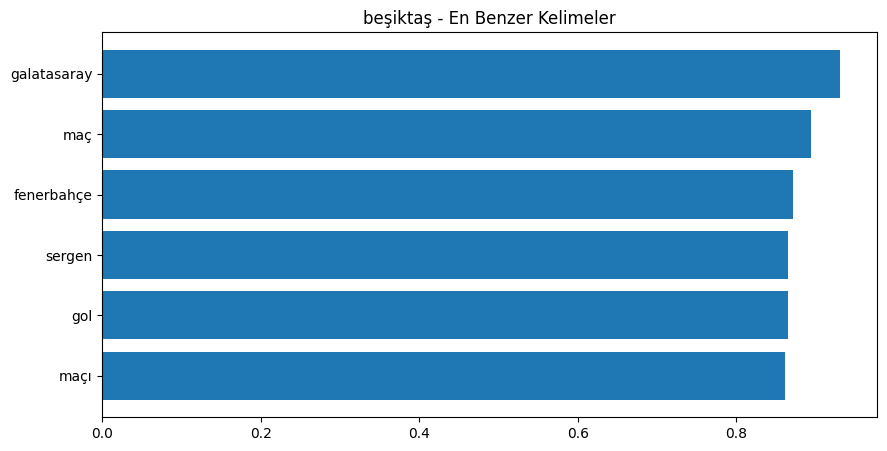

In [ ]:
# En Benzer Kelimeler - örnek "cerrahi"
import matplotlib.pyplot as plt

word = "beşiktaş"
similar = model.wv.most_similar(word, topn=6)

labels = [w[0] for w in similar]
scores = [w[1] for w in similar]

plt.figure(figsize=(10,5))
plt.barh(labels, scores)
plt.gca().invert_yaxis()
plt.title(f"{word} - En Benzer Kelimeler")
plt.show()

Aşağıdaki görselleştirme ile benzer semantik alanlara ait kelimelerin uzayda birbirine yakın konumlandığı gözlemlenmiştir. Örneğin spor ile ilgili kelimeler kendi arasında, siyaset terimleri kendi arasında kümelenmiştir.

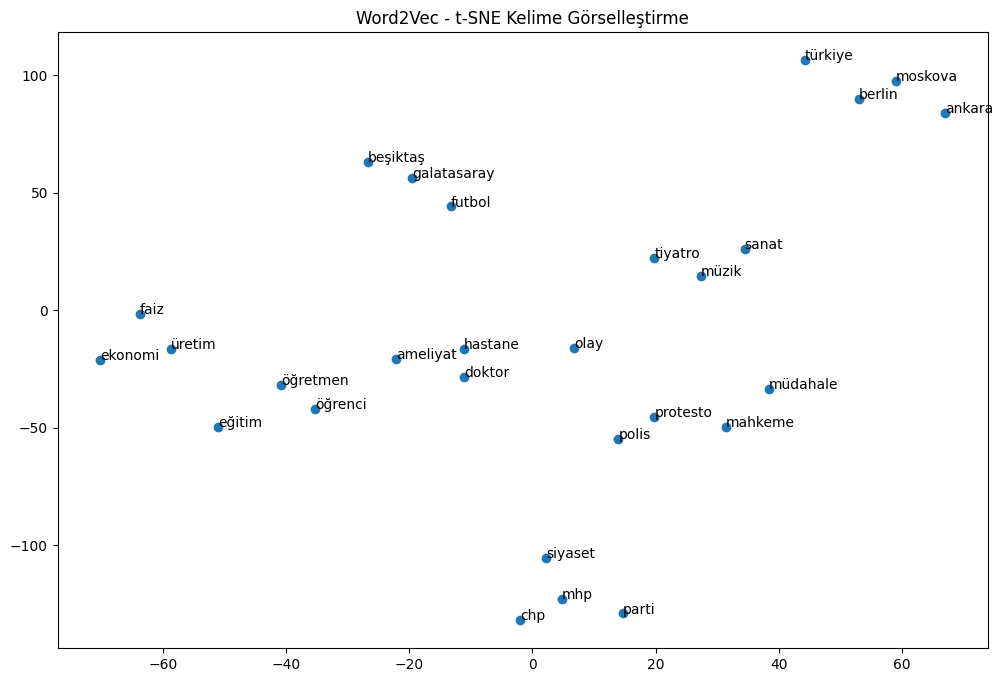

In [ ]:
#t-SNE ile Word Embedding Görselleştirme

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Görselleştirmek istediğin kelimeler
words = [
    "ankara","moskova","berlin","türkiye",
     "ekonomi","faiz","üretim",
    "siyaset", "parti","chp", "mhp",
    "polis","olay","protesto","müdahale", "mahkeme","film" "dava","ambulans"
    "okul", "öğrenci","hastane","doktor", "eğitim","tiyatro",
    "futbol", "öğretmen","beşiktaş", "galatasaray","müzik","sanat","ameliyat"
]

# Modelde olan kelimeleri filtrele
words = [w for w in words if w in model.wv.key_to_index]

# Vektörleri al
vectors = [model.wv[w] for w in words]

# t-SNE modeli
tsne = TSNE(
    n_components=2,
    perplexity=4,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

reduced = tsne.fit_transform(np.array(vectors))

# Grafik
plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1])

# Noktalara etiket ekle
for i, word in enumerate(words):
    plt.annotate(word, xy=(reduced[i, 0], reduced[i, 1]))

plt.title("Word2Vec - t-SNE Kelime Görselleştirme")
plt.show()